In [13]:
from pathlib import Path
import sys

# Add notebook directory so reactor_parameters can be found
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_nb_dir = next((p for p in _candidates if (p / "reactor_parameters.py").is_file()), None)
if _nb_dir is not None and str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import numpy as np
import matplotlib.pyplot as plt

from reactor_parameters import *


### Generic reactor parameters


In [14]:
initial_T = 10.0  # keV
final_T = 70.0  # keV
total_transient = 3600.0  # s
temperature_shape = 4.0
V_DHe3 = 354.0  # m^3

initial_deuterium_fraction = 0.50
initial_tritium_fraction = 0.50
initial_he3_fraction = 0.00

initial_tritium_inventory_kg = 2.0
tritium_inventory_floor_kg = 0.001
tritium_inventory_taper_fraction = 0.05
target_fusion_power_mw = 650.0
power_target_search_points = 301
power_target_selection_tolerance_mw = 5.0
minority_feedback_tau = max(float(total_transient) / 12.0, float(tau_p_T))
simulation_end = float(total_transient)


### Power-Targeted DT to DHe3 Transition

Start from a 50-50 D-T plasma at `initial_T` with 2 kg of tritium storage. The ion temperature is prescribed as a smooth time-only ramp from `initial_T` to `final_T` over `total_transient`, and the custom fueling law computes the T/He3 mix that best matches `target_fusion_power_mw` at the current temperature.

In [15]:
species_params = {
    "D": {
        "tau_p": float(tau_p_T),
        "lambda_decay": float(SPECIES_DEFAULTS["D"]["lambda_decay"]),
        "tau_ifc": float(np.inf),
        "tau_ofc": float(np.inf),
        "N_stor_min": 0.0,
        "Ndot_max": float(np.inf),
        "inject_from_storage": False,
        "injection_mode": "auto",
        "enable_plasma_channel": True,
    },
    "T": {
        "tau_p": float(tau_p_T),
        "lambda_decay": float(SPECIES_DEFAULTS["T"]["lambda_decay"]),
        "tau_ifc": float(np.inf),
        "tau_ofc": float(np.inf),
        "N_stor_min": float(tritium_inventory_floor_kg / species_mass["T"]),
        "Ndot_max": float(np.inf),
        "inject_from_storage": True,
        "injection_mode": "custom",
        "enable_plasma_channel": True,
    },
    "He3": {
        "tau_p": float(tau_p_T),
        "lambda_decay": float(SPECIES_DEFAULTS["He3"]["lambda_decay"]),
        "tau_ifc": float(np.inf),
        "tau_ofc": float(np.inf),
        "N_stor_min": 0.0,
        "Ndot_max": float(np.inf),
        "inject_from_storage": False,
        "injection_mode": "custom",
        "enable_plasma_channel": True,
    },
    "He4": {
        "tau_p": float(tau_p_T),
        "lambda_decay": float(SPECIES_DEFAULTS["He4"]["lambda_decay"]),
        "tau_ifc": float(np.inf),
        "tau_ofc": float(np.inf),
        "N_stor_min": 0.0,
        "Ndot_max": 0.0,
        "inject_from_storage": False,
        "injection_mode": "off",
        "enable_plasma_channel": True,
    },
}

initial_conditions = {
    "D": {
        "f_0": float(initial_deuterium_fraction),
        "N_ofc_0": float(SPECIES_DEFAULTS["D"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["D"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["D"]["N_stor_0"]),
    },
    "T": {
        "f_0": float(initial_tritium_fraction),
        "N_ofc_0": float(SPECIES_DEFAULTS["T"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["T"]["N_ifc_0"]),
        "N_stor_0": float(initial_tritium_inventory_kg / species_mass["T"]),
    },
    "He3": {
        "f_0": float(initial_he3_fraction),
        "N_ofc_0": float(SPECIES_DEFAULTS["He3"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["He3"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["He3"]["N_stor_0"]),
    },
    "He4": {
        "f_0": 0.0,
        "N_ofc_0": float(SPECIES_DEFAULTS["He4"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["He4"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["He4"]["N_stor_0"]),
    },
}


### Reactivities And Weights

In [16]:
reactivities_dhe3 = compute_reactivities_from_functions(float(initial_T))
minority_total_fraction = float(initial_tritium_fraction + initial_he3_fraction)
reactivity_channels = (
    "sigmav_DD_p",
    "sigmav_DD_n",
    "sigmav_DT",
    "sigmav_DHe3",
    "sigmav_TT",
    "sigmav_He3He3",
    "sigmav_THe3_ch1",
    "sigmav_THe3_ch2",
    "sigmav_THe3_ch3",
)
fusion_energy_by_channel = {channel: float(REACTION_ENERGY_BY_CHANNEL[channel]) for channel in reactivity_channels}

def _ctx_nonnegative(ctx, key):
    value = float(ctx.get(key, 0.0))
    return max(value, 0.0) if np.isfinite(value) else 0.0

def _smooth_arctan_progress(progress, shape=4.0):
    progress = float(np.clip(progress, 0.0, 1.0))
    shape = max(float(shape), 1.0e-6)
    norm = np.arctan(shape)
    return 0.5 + 0.5 * np.arctan(shape * (2.0 * progress - 1.0)) / norm

def build_time_temperature_function(initial_T, final_T, total_transient, *, shape=4.0):
    initial_T = float(initial_T)
    final_T = float(final_T)
    total_transient = max(float(total_transient), 1.0e-300)

    def temperature_fn(ctx):
        t = max(float(ctx.get("t", 0.0)), 0.0)
        progress = min(t / total_transient, 1.0)
        smooth = _smooth_arctan_progress(progress, shape=shape)
        return initial_T + (final_T - initial_T) * smooth

    return temperature_fn

def _reaction_terms_from_densities(n_D, n_T, n_He3, ctx):
    sigmav_DD_p = float(ctx.get("sigmav_DD_p", 0.0))
    sigmav_DD_n = float(ctx.get("sigmav_DD_n", 0.0))
    sigmav_DT = float(ctx.get("sigmav_DT", 0.0))
    sigmav_DHe3 = float(ctx.get("sigmav_DHe3", 0.0))
    sigmav_TT = float(ctx.get("sigmav_TT", 0.0))
    sigmav_He3He3 = float(ctx.get("sigmav_He3He3", 0.0))
    sigmav_THe3_ch1 = float(ctx.get("sigmav_THe3_ch1", 0.0))
    sigmav_THe3_ch2 = float(ctx.get("sigmav_THe3_ch2", 0.0))
    sigmav_THe3_ch3 = float(ctx.get("sigmav_THe3_ch3", 0.0))

    R_DD_p = 0.5 * n_D * n_D * sigmav_DD_p
    R_DD_n = 0.5 * n_D * n_D * sigmav_DD_n
    R_DT = n_D * n_T * sigmav_DT
    R_DHe3 = n_D * n_He3 * sigmav_DHe3
    R_TT = 0.5 * n_T * n_T * sigmav_TT
    R_He3He3 = 0.5 * n_He3 * n_He3 * sigmav_He3He3
    R_THe3_ch1 = n_T * n_He3 * sigmav_THe3_ch1
    R_THe3_ch2 = n_T * n_He3 * sigmav_THe3_ch2
    R_THe3_ch3 = n_T * n_He3 * sigmav_THe3_ch3
    R_THe3_total = R_THe3_ch1 + R_THe3_ch2 + R_THe3_ch3

    return {
        "T": R_DD_p - R_DT - 2.0 * R_TT - R_THe3_total,
        "He3": R_DD_n - R_DHe3 - 2.0 * R_He3He3 - R_THe3_total,
    }

def _reaction_terms_from_context(ctx):
    return _reaction_terms_from_densities(
        _ctx_nonnegative(ctx, "n_D"),
        _ctx_nonnegative(ctx, "n_T"),
        _ctx_nonnegative(ctx, "n_He3"),
        ctx,
    )

def _power_grid_from_target_minorities(n_D, n_T_grid, n_He3_grid, ctx, V_case):
    sigmav_DD_p = float(ctx.get("sigmav_DD_p", 0.0))
    sigmav_DD_n = float(ctx.get("sigmav_DD_n", 0.0))
    sigmav_DT = float(ctx.get("sigmav_DT", 0.0))
    sigmav_DHe3 = float(ctx.get("sigmav_DHe3", 0.0))
    sigmav_TT = float(ctx.get("sigmav_TT", 0.0))
    sigmav_He3He3 = float(ctx.get("sigmav_He3He3", 0.0))
    sigmav_THe3_ch1 = float(ctx.get("sigmav_THe3_ch1", 0.0))
    sigmav_THe3_ch2 = float(ctx.get("sigmav_THe3_ch2", 0.0))
    sigmav_THe3_ch3 = float(ctx.get("sigmav_THe3_ch3", 0.0))

    return float(V_case) * (
        0.5 * n_D**2 * sigmav_DD_p * fusion_energy_by_channel["sigmav_DD_p"]
        + 0.5 * n_D**2 * sigmav_DD_n * fusion_energy_by_channel["sigmav_DD_n"]
        + n_D * n_T_grid * sigmav_DT * fusion_energy_by_channel["sigmav_DT"]
        + n_D * n_He3_grid * sigmav_DHe3 * fusion_energy_by_channel["sigmav_DHe3"]
        + 0.5 * n_T_grid**2 * sigmav_TT * fusion_energy_by_channel["sigmav_TT"]
        + 0.5 * n_He3_grid**2 * sigmav_He3He3 * fusion_energy_by_channel["sigmav_He3He3"]
        + n_T_grid * n_He3_grid * sigmav_THe3_ch1 * fusion_energy_by_channel["sigmav_THe3_ch1"]
        + n_T_grid * n_He3_grid * sigmav_THe3_ch2 * fusion_energy_by_channel["sigmav_THe3_ch2"]
        + n_T_grid * n_He3_grid * sigmav_THe3_ch3 * fusion_energy_by_channel["sigmav_THe3_ch3"]
    ) * 1.0e-6

def _power_target_state(ctx, *, target_power_mw, total_minority_fraction, search_points, selection_tolerance_mw):
    n_tot_local = max(float(ctx.get("n_tot", 0.0)), 0.0)
    V_case = float(ctx.get("V_plasma", 0.0))
    target_power_mw = float(target_power_mw)
    if (
        (n_tot_local <= 0.0)
        or (not np.isfinite(V_case))
        or (V_case <= 0.0)
        or (not np.isfinite(target_power_mw))
        or (target_power_mw < 0.0)
    ):
        return None

    n_He4_current = _ctx_nonnegative(ctx, "n_He4")
    available_non_ash = max(n_tot_local - n_He4_current, 0.0)
    minority_density = min(float(total_minority_fraction) * n_tot_local, available_non_ash)
    minority_fraction_effective = minority_density / n_tot_local if n_tot_local > 0.0 else 0.0
    n_D_target = max(available_non_ash - minority_density, 0.0)

    n_points = max(int(search_points), 2)
    f_T_grid = np.linspace(0.0, minority_fraction_effective, n_points)
    n_T_grid = n_tot_local * f_T_grid
    n_He3_grid = minority_density - n_T_grid
    power_grid = np.asarray(
        _power_grid_from_target_minorities(n_D_target, n_T_grid, n_He3_grid, ctx, V_case),
        dtype=float,
    )

    finite_mask = np.isfinite(power_grid)
    if finite_mask.sum() < 2:
        return None
    if not np.all(finite_mask):
        f_T_grid = f_T_grid[finite_mask]
        n_T_grid = n_T_grid[finite_mask]
        n_He3_grid = n_He3_grid[finite_mask]
        power_grid = power_grid[finite_mask]

    current_f_T = 0.0
    if n_tot_local > 0.0:
        current_f_T = np.clip(_ctx_nonnegative(ctx, "n_T") / n_tot_local, 0.0, minority_fraction_effective)

    power_delta = power_grid - target_power_mw
    sign_change_idx = np.flatnonzero(power_delta[:-1] * power_delta[1:] <= 0.0)

    if sign_change_idx.size > 0:
        f_candidates = np.empty(sign_change_idx.size, dtype=float)
        p_candidates = np.empty(sign_change_idx.size, dtype=float)
        for j, idx_pair in enumerate(sign_change_idx):
            f0 = float(f_T_grid[idx_pair])
            f1 = float(f_T_grid[idx_pair + 1])
            p0 = float(power_grid[idx_pair])
            p1 = float(power_grid[idx_pair + 1])
            dp = p1 - p0
            if (not np.isfinite(dp)) or (abs(dp) <= 1.0e-12 * max(1.0, abs(p0), abs(p1))):
                weight = 0.5
            else:
                weight = np.clip((target_power_mw - p0) / dp, 0.0, 1.0)
            f_candidates[j] = f0 + weight * (f1 - f0)
            p_candidates[j] = p0 + weight * (p1 - p0)
        idx_best = int(np.argmin(np.abs(f_candidates - current_f_T)))
        f_T_target = float(f_candidates[idx_best])
        power_match = float(p_candidates[idx_best])
    else:
        power_scale = max(
            float(selection_tolerance_mw),
            0.02 * max(target_power_mw, float(np.max(np.abs(power_grid))), 1.0),
            1.0,
        )
        f_scale = max(minority_fraction_effective / 8.0, 1.0 / max(float(search_points), 2.0))
        objective = ((power_grid - target_power_mw) / power_scale) ** 2 + ((f_T_grid - current_f_T) / f_scale) ** 2
        idx_best = int(np.argmin(objective))
        f_T_target = float(f_T_grid[idx_best])
        power_match = float(power_grid[idx_best])

    f_T_target = float(np.clip(f_T_target, 0.0, minority_fraction_effective))
    n_T_target = float(n_tot_local * f_T_target)
    n_He3_target = float(max(minority_density - n_T_target, 0.0))
    f_He3_target = float(n_He3_target / n_tot_local) if n_tot_local > 0.0 else 0.0
    return {
        "f_T": f_T_target,
        "f_He3": f_He3_target,
        "n_D": float(n_D_target),
        "n_T": n_T_target,
        "n_He3": n_He3_target,
        "power_mw": power_match,
    }

def _limit_tritium_request(request, ctx, *, total_transient, feedback_tau, inventory_taper_atoms):
    request = max(float(request), 0.0)
    if request <= 0.0:
        return 0.0

    current_time = max(float(ctx.get("t", 0.0)), 0.0)
    N_stor = _ctx_nonnegative(ctx, "N_stor")
    N_stor_min = _ctx_nonnegative(ctx, "N_stor_min")
    remaining_inventory = max(N_stor - N_stor_min, 0.0)
    if remaining_inventory <= 0.0:
        return 0.0

    remaining_time = max(float(total_transient) - current_time, float(feedback_tau))
    request = min(request, remaining_inventory / remaining_time)
    request *= remaining_inventory / (remaining_inventory + max(float(inventory_taper_atoms), 1.0e-300))
    return max(request, 0.0)

def build_power_target_request(
    species_name,
    *,
    target_power_mw,
    total_minority_fraction,
    feedback_tau,
    total_transient,
    search_points,
    selection_tolerance_mw,
    inventory_taper_atoms=0.0,
):
    species_name = str(species_name)
    feedback_tau = max(float(feedback_tau), 1.0e-300)
    total_transient = max(float(total_transient), feedback_tau)
    search_points = max(int(search_points), 2)
    selection_tolerance_mw = max(float(selection_tolerance_mw), 0.0)
    inventory_taper_atoms = max(float(inventory_taper_atoms), 1.0e-300)

    def request_fn(ctx):
        target_state = _power_target_state(
            ctx,
            target_power_mw=target_power_mw,
            total_minority_fraction=total_minority_fraction,
            search_points=search_points,
            selection_tolerance_mw=selection_tolerance_mw,
        )
        if target_state is None:
            return 0.0

        n_tot_local = max(float(ctx.get("n_tot", 0.0)), 0.0)
        V_case = float(ctx.get("V_plasma", 0.0))
        tau_p_local = max(float(ctx.get("tau_p", feedback_tau)), 1.0e-300)
        if (not np.isfinite(V_case)) or V_case <= 0.0:
            return 0.0

        if species_name == "T":
            target_fraction = target_state["f_T"]
        elif species_name == "He3":
            target_fraction = target_state["f_He3"]
        else:
            raise ValueError(f"Unsupported species_name: {species_name}")

        n_target = target_fraction * n_tot_local
        n_current = _ctx_nonnegative(ctx, f"n_{species_name}")
        if n_current >= n_target:
            return 0.0

        reaction_terms_target = _reaction_terms_from_densities(
            target_state["n_D"],
            target_state["n_T"],
            target_state["n_He3"],
            ctx,
        )
        if species_name == "T":
            plasma_net_target = reaction_terms_target["T"] - target_state["n_T"] / tau_p_local
        else:
            plasma_net_target = reaction_terms_target["He3"] - target_state["n_He3"] / tau_p_local

        request = -V_case * plasma_net_target + V_case * (n_target - n_current) / feedback_tau
        if (not np.isfinite(request)) or request <= 0.0:
            return 0.0

        if species_name == "T":
            request = _limit_tritium_request(
                request,
                ctx,
                total_transient=total_transient,
                feedback_tau=feedback_tau,
                inventory_taper_atoms=inventory_taper_atoms,
            )

        Ndot_cap = float(ctx.get("Ndot_max", np.inf))
        if np.isfinite(Ndot_cap):
            request = min(request, max(Ndot_cap, 0.0))
        return max(float(request), 0.0)

    return request_fn

temperature_function_dhe3 = build_time_temperature_function(
    initial_T=initial_T,
    final_T=final_T,
    total_transient=total_transient,
    shape=temperature_shape,
)

initial_tritium_inventory_atoms = float(initial_tritium_inventory_kg / species_mass["T"])
tritium_inventory_floor_atoms = float(tritium_inventory_floor_kg / species_mass["T"])
tritium_inventory_taper_atoms = max(
    (initial_tritium_inventory_atoms - tritium_inventory_floor_atoms)
    * float(tritium_inventory_taper_fraction),
    1.0,
)

species_params["T"]["injection_custom_function"] = build_power_target_request(
    "T",
    target_power_mw=target_fusion_power_mw,
    total_minority_fraction=minority_total_fraction,
    feedback_tau=minority_feedback_tau,
    total_transient=total_transient,
    search_points=power_target_search_points,
    selection_tolerance_mw=power_target_selection_tolerance_mw,
    inventory_taper_atoms=tritium_inventory_taper_atoms,
)
species_params["He3"]["injection_custom_function"] = build_power_target_request(
    "He3",
    target_power_mw=target_fusion_power_mw,
    total_minority_fraction=minority_total_fraction,
    feedback_tau=minority_feedback_tau,
    total_transient=total_transient,
    search_points=power_target_search_points,
    selection_tolerance_mw=power_target_selection_tolerance_mw,
)

injection_mix_weights_dhe3 = {"D": 1.0}


### Solve


In [17]:
res_dhe3 = solve_multispecies_ode_system(
    V_plasma=float(V_DHe3),
    T_i=float(initial_T),
    n_tot=float(n_tot),
    species_params=species_params,
    initial_conditions=initial_conditions,
    TBR_DT=0,
    TBR_DDn=0,
    max_simulation_time=float(simulation_end),
    vector_length=int(vector_length),
    reactivities=reactivities_dhe3,
    injection_mix_weights=injection_mix_weights_dhe3,
    temperature_function=temperature_function_dhe3,
)

In [18]:
# ----- Guard: check for solver failure -----
if "t" not in res_dhe3:
    raise RuntimeError(
        f"Solver failed without returning time arrays.\n"
        f"  error: {res_dhe3.get('error', 'unknown')}"
    )

print("Time-driven DT -> DHe3 transition")
print(f"  solved = {res_dhe3.get('sol_success', False)}")
if res_dhe3.get('error'):
    print(f"  error: {res_dhe3['error']}")
t_end = float(np.asarray(res_dhe3.get('t', [np.nan]), dtype=float)[-1])
T_summary = np.asarray(res_dhe3.get('T_i', [np.nan]), dtype=float)
T_stor_summary = np.asarray(res_dhe3.get('N_stor_T', [np.nan]), dtype=float) * species_mass['T']
print(f"  t_end = {t_end:.6e} s ({t_end/3600.0:.3f} h)")
print(f"  T_i: {float(T_summary[0]):.2f} -> {float(T_summary[-1]):.2f} keV")
print(f"  T storage: {float(T_stor_summary[0]):.3f} -> {float(T_stor_summary[-1]):.3f} kg")


Time-driven DT -> DHe3 transition
  solved = True
  t_end = 3.600000e+03 s (1.000 h)
  T_i: 10.00 -> 70.00 keV
  T storage: 2.000 -> 1.883 kg


### Power Calculation


In [19]:
if not res_dhe3.get("sol_success", False):
    raise RuntimeError(f"Solver did not converge cleanly.\n  error: {res_dhe3.get('error', 'unknown')}")

t_ref = np.asarray(res_dhe3["t"], dtype=float)
n_D = np.maximum(np.asarray(res_dhe3.get("n_D", np.zeros_like(t_ref)), dtype=float), 0.0)
n_T = np.maximum(np.asarray(res_dhe3.get("n_T", np.zeros_like(t_ref)), dtype=float), 0.0)
n_He3 = np.maximum(np.asarray(res_dhe3.get("n_He3", np.zeros_like(t_ref)), dtype=float), 0.0)
T_profile = np.asarray(res_dhe3.get("T_i", np.full_like(t_ref, float(initial_T))), dtype=float)

reactivity_profiles = {}
for channel in reactivity_channels:
    reactivity_profiles[channel] = np.zeros_like(T_profile, dtype=float)

for idx, T_keV in enumerate(T_profile):
    local_reactivities = compute_reactivities_from_functions(float(T_keV))
    for channel in reactivity_channels:
        reactivity_profiles[channel][idx] = float(local_reactivities[channel])

energy_by_channel = {channel: float(REACTION_ENERGY_BY_CHANNEL[channel]) for channel in reactivity_channels}

P_DDn = 0.5 * n_D**2 * reactivity_profiles["sigmav_DD_n"] * float(V_DHe3) * energy_by_channel["sigmav_DD_n"]
P_DDp = 0.5 * n_D**2 * reactivity_profiles["sigmav_DD_p"] * float(V_DHe3) * energy_by_channel["sigmav_DD_p"]
P_DT = n_D * n_T * reactivity_profiles["sigmav_DT"] * float(V_DHe3) * energy_by_channel["sigmav_DT"]
P_DHe3 = n_D * n_He3 * reactivity_profiles["sigmav_DHe3"] * float(V_DHe3) * energy_by_channel["sigmav_DHe3"]
P_TT = 0.5 * n_T**2 * reactivity_profiles["sigmav_TT"] * float(V_DHe3) * energy_by_channel["sigmav_TT"]
P_He3He3 = 0.5 * n_He3**2 * reactivity_profiles["sigmav_He3He3"] * float(V_DHe3) * energy_by_channel["sigmav_He3He3"]
P_THe3_ch1 = n_T * n_He3 * reactivity_profiles["sigmav_THe3_ch1"] * float(V_DHe3) * energy_by_channel["sigmav_THe3_ch1"]
P_THe3_ch2 = n_T * n_He3 * reactivity_profiles["sigmav_THe3_ch2"] * float(V_DHe3) * energy_by_channel["sigmav_THe3_ch2"]
P_THe3_ch3 = n_T * n_He3 * reactivity_profiles["sigmav_THe3_ch3"] * float(V_DHe3) * energy_by_channel["sigmav_THe3_ch3"]
P_DT_eq = 0.25 * float(n_tot)**2 * reactivity_profiles["sigmav_DT"] * float(V_DHe3) * energy_by_channel["sigmav_DT"]

P_DDn = np.asarray(P_DDn, dtype=float)
P_DDp = np.asarray(P_DDp, dtype=float)
P_DT = np.asarray(P_DT, dtype=float)
P_DHe3 = np.asarray(P_DHe3, dtype=float)
P_TT = np.asarray(P_TT, dtype=float)
P_He3He3 = np.asarray(P_He3He3, dtype=float)
P_THe3_ch1 = np.asarray(P_THe3_ch1, dtype=float)
P_THe3_ch2 = np.asarray(P_THe3_ch2, dtype=float)
P_THe3_ch3 = np.asarray(P_THe3_ch3, dtype=float)
P_DT_eq = np.asarray(P_DT_eq, dtype=float)
P_fusion_total = np.asarray(P_DDn + P_DDp + P_DT + P_DHe3 + P_TT + P_He3He3 + P_THe3_ch1 + P_THe3_ch2 + P_THe3_ch3, dtype=float)

print(f"T_i(final): {float(T_profile[-1]):.3f} keV")
print(f"P_fus(final): {float(P_fusion_total[-1]) / 1e6:.3f} MW")


T_i(final): 70.000 keV
P_fus(final): 649.570 MW


### Plot


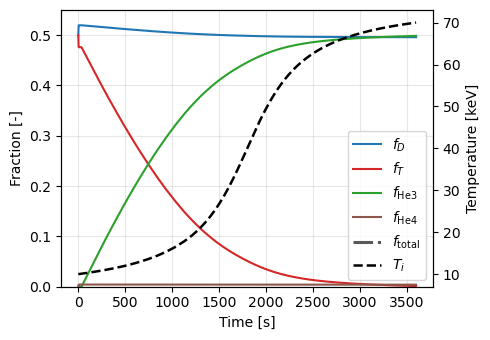

In [26]:
# Plasma fractions and ion temperature
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
t_hours = np.asarray(res_dhe3["t"], dtype=float) / 3600.0
t_sec = np.asarray(res_dhe3["t"], dtype=float)
FRACTION_STYLE = {
    "D": {"label": r"$f_D$", "color": "tab:blue"},
    "T": {"label": r"$f_T$", "color": "tab:red"},
    "He3": {"label": r"$f_{\mathrm{He3}}$", "color": "tab:green"},
    "He4": {"label": r"$f_{\mathrm{He4}}$", "color": "tab:brown"},
}
for sp in SPECIES:
    key = f"n_{sp}"
    if key in res_dhe3:
        style = FRACTION_STYLE.get(sp, {"label": rf"$f_{{{sp}}}$", "color": None})
        ax.plot(
            t_sec,
            np.asarray(res_dhe3[key], dtype=float) / n_tot,
            label=style["label"],
            color=style["color"],
        )
total = np.zeros_like(t_hours, dtype=float)
for sp in SPECIES:
    key = f"n_{sp}"
    if key in res_dhe3:
        total = total + np.asarray(res_dhe3[key], dtype=float)
ax.plot(t_sec, total / n_tot, color="0.35", lw=2.2, ls='-.', label=r"$f_{\mathrm{total}}$")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Fraction [-]")
ax.set_ylim(0.0, 0.55)
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ax2.plot(t_sec, T_profile, color="k", ls="--", lw=1.8, label=r"$T_i$")
ax2.set_ylabel("Temperature [keV]")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()


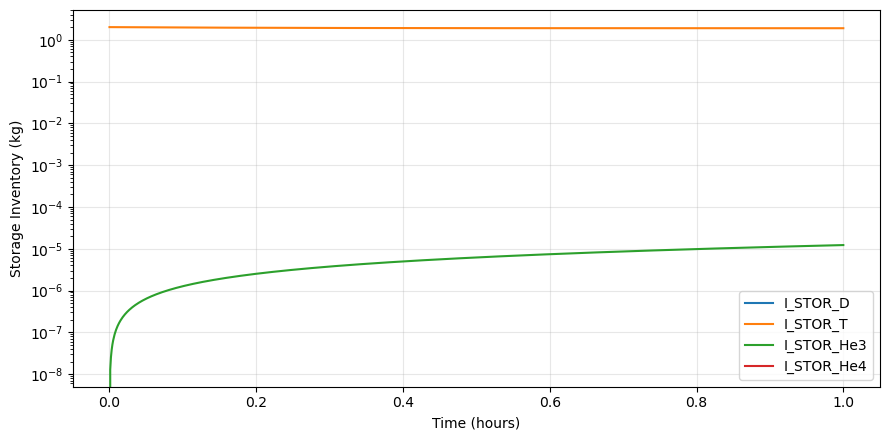

In [21]:
# Storage inventories
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_hours = np.asarray(res_dhe3["t"], dtype=float) / 3600.0
for sp in SPECIES:
    key = f"N_stor_{sp}"
    if key in res_dhe3:
        ax.plot(t_hours, np.asarray(res_dhe3[key], dtype=float) * species_mass[sp], label=f"I_STOR_{sp}")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Storage Inventory (kg)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


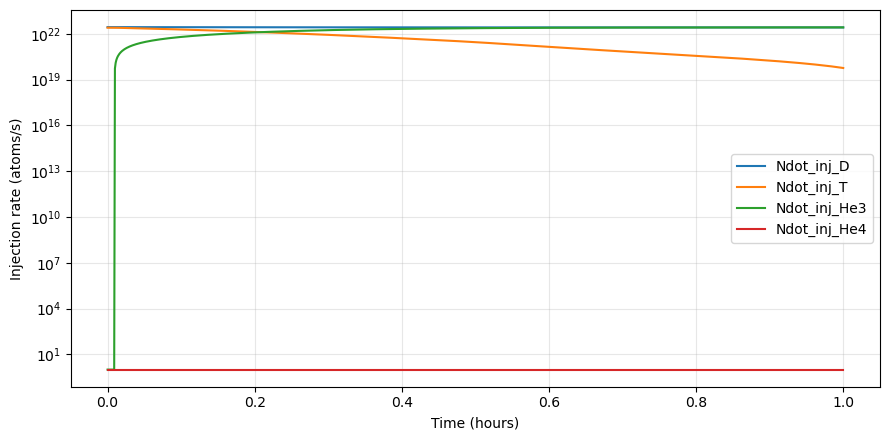

In [22]:
# Injection rates
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_hours = np.asarray(res_dhe3["t"], dtype=float) / 3600.0
for sp in SPECIES:
    key = f"Ndot_inj_{sp}"
    if key in res_dhe3:
        ax.plot(t_hours, np.maximum(np.asarray(res_dhe3[key], dtype=float), 1.0), label=f"Ndot_inj_{sp}")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Injection rate (atoms/s)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


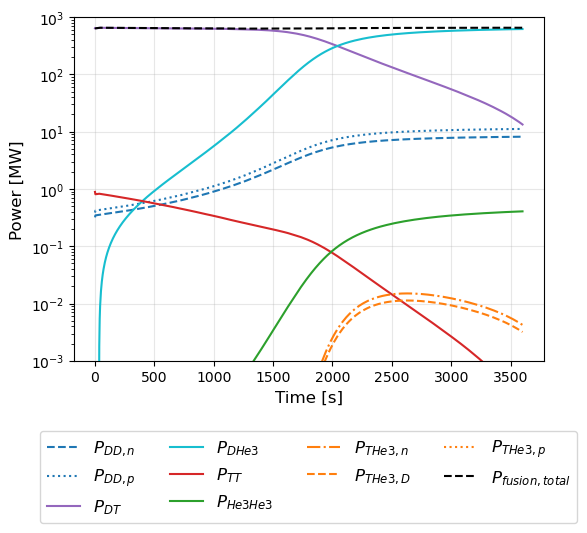

In [37]:
# Fusion powers
fig, ax = plt.subplots(1, 1, figsize=(6, 6.5))
t_sec = np.asarray(res_dhe3["t"], dtype=float)
REACTION_COLORS = {
    "DT": "tab:purple",
    "DD": "tab:blue",
    "DHe3": "tab:cyan",
    "TT": "tab:red",
    "He3He3": "tab:green",
    "THe3": "tab:orange",
}
CHANNEL_STYLE = {
    "DT": {"color": REACTION_COLORS["DT"], "linestyle": "-"},
    "DD_n": {"color": REACTION_COLORS["DD"], "linestyle": "--"},
    "DD_p": {"color": REACTION_COLORS["DD"], "linestyle": ":"},
    "DHe3": {"color": REACTION_COLORS["DHe3"], "linestyle": "-"},
    "TT": {"color": REACTION_COLORS["TT"], "linestyle": "-"},
    "He3He3": {"color": REACTION_COLORS["He3He3"], "linestyle": "-"},
    "THe3_ch1": {"color": REACTION_COLORS["THe3"], "linestyle": "-."},
    "THe3_ch2": {"color": REACTION_COLORS["THe3"], "linestyle": "--"},
    "THe3_ch3": {"color": REACTION_COLORS["THe3"], "linestyle": ":"},
}
reaction_series = [
    {"label": r"$P_{DD,n}$", "series": P_DDn, **CHANNEL_STYLE["DD_n"]},
    {"label": r"$P_{DD,p}$", "series": P_DDp, **CHANNEL_STYLE["DD_p"]},
    {"label": r"$P_{DT}$", "series": P_DT, **CHANNEL_STYLE["DT"]},
    {"label": r"$P_{DHe3}$", "series": P_DHe3, **CHANNEL_STYLE["DHe3"]},
    {"label": r"$P_{TT}$", "series": P_TT, **CHANNEL_STYLE["TT"]},
    {"label": r"$P_{He3He3}$", "series": P_He3He3, **CHANNEL_STYLE["He3He3"]},
    {"label": r"$P_{THe3,n}$", "series": P_THe3_ch1, **CHANNEL_STYLE["THe3_ch1"]},
    {"label": r"$P_{THe3,D}$", "series": P_THe3_ch2, **CHANNEL_STYLE["THe3_ch2"]},
    {"label": r"$P_{THe3,p}$", "series": P_THe3_ch3, **CHANNEL_STYLE["THe3_ch3"]},
    {"label": r"$P_{fusion,total}$", "series": P_fusion_total, "color": "k", "linestyle": "--"},
]
for channel in reaction_series:
    ax.plot(
        t_sec,
        np.asarray(channel["series"], dtype=float) * 1.0e-6,
        label=channel["label"],
        color=channel["color"],
        linestyle=channel["linestyle"],
    )
ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel("Power [MW]", fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
ax.set_ylim(1e-3, 1e3)
ax.legend(fontsize=12, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout(rect=(0, 0.12, 1, 1))
plt.show()


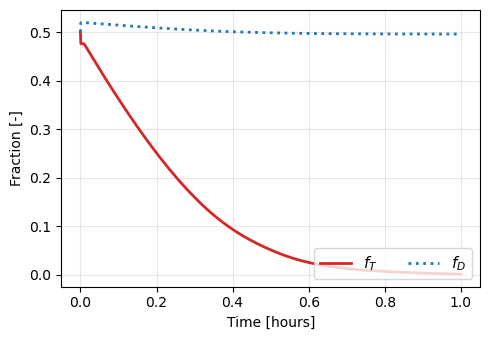

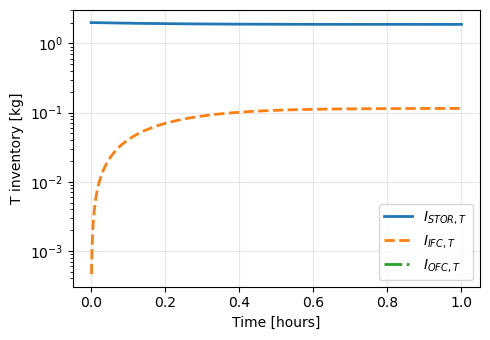

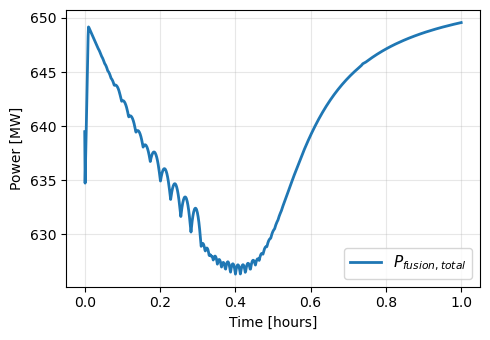

In [24]:
# Focused DT-style summary plots
case_color = "tab:blue"
t_hours = np.asarray(res_dhe3["t"], dtype=float) / 3600.0

f_T = np.asarray(res_dhe3.get("n_T", np.zeros_like(t_hours)), dtype=float) / n_tot
f_D = np.asarray(res_dhe3.get("n_D", np.zeros_like(t_hours)), dtype=float) / n_tot

stor_kg = np.asarray(res_dhe3.get("N_stor_T", np.zeros_like(t_hours)), dtype=float) * species_mass["T"]
ifc_kg = np.asarray(res_dhe3.get("N_ifc_T", np.zeros_like(t_hours)), dtype=float) * species_mass["T"]
ofc_kg = np.asarray(res_dhe3.get("N_ofc_T", np.zeros_like(t_hours)), dtype=float) * species_mass["T"]

stor_kg_plot = np.where(stor_kg > 0.0, stor_kg, np.nan)
ifc_kg_plot = np.where(ifc_kg > 0.0, ifc_kg, np.nan)
ofc_kg_plot = np.where(ofc_kg > 0.0, ofc_kg, np.nan)
power_mw = np.asarray(P_fusion_total, dtype=float) * 1.0e-6

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
ax.plot(t_hours, f_T, color="tab:red", lw=2.0, label=rf"$f_T$")
ax.plot(t_hours, f_D, color="tab:blue", lw=2.0, ls=":", label=rf"$f_D$")
ax.set_xlabel("Time [hours]")
ax.set_ylabel("Fraction [-]")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=11, loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
ax.plot(t_hours, stor_kg_plot, color=case_color, lw=2.0, label=r"$I_{STOR,T}$")
ax.plot(t_hours, ifc_kg_plot, color="tab:orange", lw=2.0, ls="--", label=r"$I_{IFC,T}$")
ax.plot(t_hours, ofc_kg_plot, color="tab:green", lw=2.0, ls="-.", label=r"$I_{OFC,T}$")
ax.set_xlabel("Time [hours]")
ax.set_ylabel("T inventory [kg]")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
ax.plot(t_hours, power_mw, color=case_color, lw=2.0, label=r"$P_{fusion,total}$")
ax.set_xlabel("Time [hours]")
ax.set_ylabel("Power [MW]")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc="lower right")
plt.tight_layout()
plt.show()
